# Part 4 - Hybrid CNN-Transformer on CIFAR-10
This notebook compares two hybrid models using full model names.

In [1]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


In [3]:
BATCH_SIZE = 128
EPOCHS = 10
LR = 1e-3
NUM_CLASSES = 10
NUM_WORKERS = 2


In [4]:
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))
print("Classes:", train_dataset.classes)


100%|██████████| 170M/170M [00:04<00:00, 40.7MB/s]


Train size: 50000
Test size: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [5]:
class SmallCNNBackbone(nn.Module):
    def __init__(self, out_channels=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, out_channels, kernel_size=3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.features(x)


In [6]:
class CNNTransformer64Tokens(nn.Module):
    def __init__(self, num_classes=10, embed_dim=128, num_heads=4, num_layers=2):
        super().__init__()
        self.backbone = SmallCNNBackbone(out_channels=embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.pos_embedding = nn.Parameter(torch.randn(1, 64, embed_dim))
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        x = x + self.pos_embedding[:, :H * W, :]
        x = self.transformer(x)
        x = x.mean(dim=1)
        x = self.classifier(x)
        return x


In [7]:
class CNNTransformer16Tokens(nn.Module):
    def __init__(self, num_classes=10, embed_dim=128, num_heads=4, num_layers=2):
        super().__init__()
        self.backbone = SmallCNNBackbone(out_channels=embed_dim)
        self.token_pool = nn.MaxPool2d(2)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.pos_embedding = nn.Parameter(torch.randn(1, 16, embed_dim))
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = self.token_pool(x)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        x = x + self.pos_embedding[:, :H * W, :]
        x = self.transformer(x)
        x = x.mean(dim=1)
        x = self.classifier(x)
        return x


In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


In [9]:
def run_training(model, train_loader, test_loader, device, epochs=10, lr=1e-3):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    start_time = time.time()

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}"
        )

    total_time = time.time() - start_time

    result = {
        "final_train_loss": history["train_loss"][-1],
        "final_train_acc": history["train_acc"][-1],
        "final_test_loss": history["test_loss"][-1],
        "final_test_acc": history["test_acc"][-1],
        "train_time_sec": total_time,
        "epochs": epochs,
        "history": history
    }

    return result


In [10]:
print("Training CNN+Transformer (64 tokens)")
result_64 = run_training(
    model=CNNTransformer64Tokens(
        num_classes=NUM_CLASSES,
        embed_dim=128,
        num_heads=4,
        num_layers=2
    ),
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs=EPOCHS,
    lr=LR
)

print("\nTraining CNN+Transformer (16 tokens)")
result_16 = run_training(
    model=CNNTransformer16Tokens(
        num_classes=NUM_CLASSES,
        embed_dim=128,
        num_heads=4,
        num_layers=2
    ),
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs=EPOCHS,
    lr=LR
)


Training CNN+Transformer (64 tokens)
Epoch [1/10] | Train Loss: 1.6988 | Train Acc: 0.3536 | Test Loss: 1.4147 | Test Acc: 0.4703
Epoch [2/10] | Train Loss: 1.2778 | Train Acc: 0.5313 | Test Loss: 1.1710 | Test Acc: 0.5744
Epoch [3/10] | Train Loss: 1.1152 | Train Acc: 0.5967 | Test Loss: 1.0551 | Test Acc: 0.6201
Epoch [4/10] | Train Loss: 0.9946 | Train Acc: 0.6425 | Test Loss: 0.9714 | Test Acc: 0.6604
Epoch [5/10] | Train Loss: 0.9114 | Train Acc: 0.6727 | Test Loss: 0.9059 | Test Acc: 0.6820
Epoch [6/10] | Train Loss: 0.8405 | Train Acc: 0.7001 | Test Loss: 0.8462 | Test Acc: 0.7035
Epoch [7/10] | Train Loss: 0.7748 | Train Acc: 0.7254 | Test Loss: 0.8670 | Test Acc: 0.7010
Epoch [8/10] | Train Loss: 0.7254 | Train Acc: 0.7422 | Test Loss: 0.8025 | Test Acc: 0.7218
Epoch [9/10] | Train Loss: 0.6813 | Train Acc: 0.7596 | Test Loss: 0.7569 | Test Acc: 0.7366
Epoch [10/10] | Train Loss: 0.6370 | Train Acc: 0.7745 | Test Loss: 0.7748 | Test Acc: 0.7365

Training CNN+Transformer (16 to

In [11]:
def plot_comparison(hist1, hist2, label1="CNN+Transformer (64 tokens)", label2="CNN+Transformer (16 tokens)"):
    epochs = range(1, len(hist1["train_loss"]) + 1)

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, hist1["train_loss"], label=label1)
    plt.plot(epochs, hist2["train_loss"], label=label2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss by Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, hist1["test_loss"], label=label1)
    plt.plot(epochs, hist2["test_loss"], label=label2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Test Loss by Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, hist1["train_acc"], label=label1)
    plt.plot(epochs, hist2["train_acc"], label=label2)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training Accuracy by Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, hist1["test_acc"], label=label1)
    plt.plot(epochs, hist2["test_acc"], label=label2)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Test Accuracy by Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()


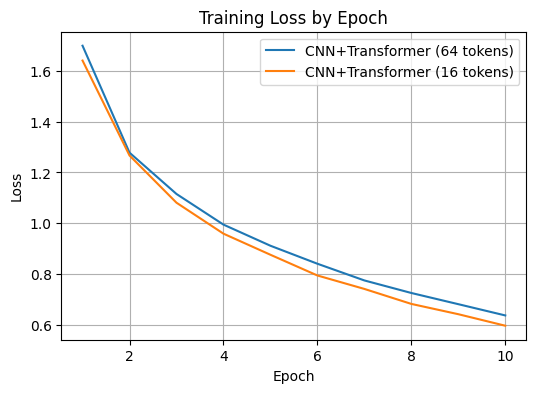

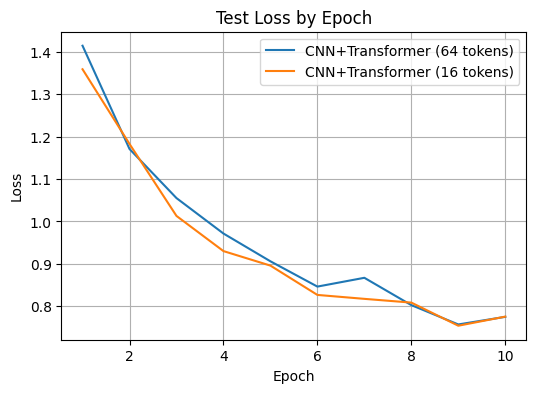

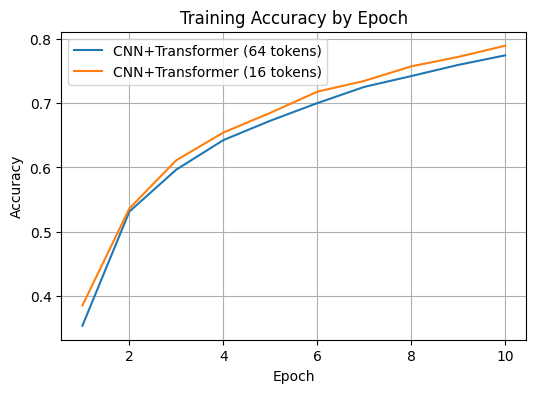

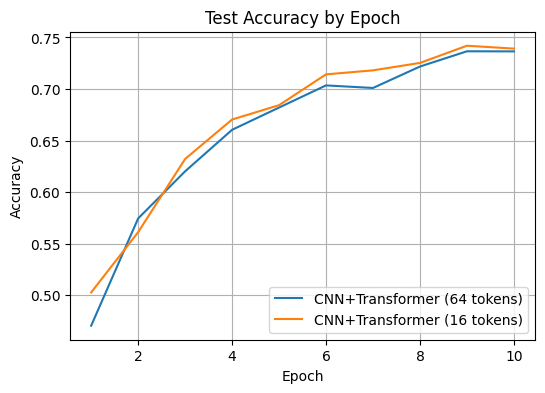

In [12]:
plot_comparison(
    result_64["history"],
    result_16["history"],
    "CNN+Transformer (64 tokens)",
    "CNN+Transformer (16 tokens)"
)


In [13]:
print("\nTable-ready results")
print("-" * 120)
print(f"{'Model':30s} {'Train Accuracy':15s} {'Test Accuracy':15s} {'Train Loss':12s} {'Test Loss':12s} {'Training Time (s)':18s}")
print("-" * 120)

print(
    f"{'CNN+Transformer (64 tokens)':30s} "
    f"{result_64['final_train_acc']:.4f}           "
    f"{result_64['final_test_acc']:.4f}           "
    f"{result_64['final_train_loss']:.4f}       "
    f"{result_64['final_test_loss']:.4f}       "
    f"{result_64['train_time_sec']:.2f}"
)

print(
    f"{'CNN+Transformer (16 tokens)':30s} "
    f"{result_16['final_train_acc']:.4f}           "
    f"{result_16['final_test_acc']:.4f}           "
    f"{result_16['final_train_loss']:.4f}       "
    f"{result_16['final_test_loss']:.4f}       "
    f"{result_16['train_time_sec']:.2f}"
)



Table-ready results
------------------------------------------------------------------------------------------------------------------------
Model                          Train Accuracy  Test Accuracy   Train Loss   Test Loss    Training Time (s) 
------------------------------------------------------------------------------------------------------------------------
CNN+Transformer (64 tokens)    0.7745           0.7365           0.6370       0.7748       164.78
CNN+Transformer (16 tokens)    0.7895           0.7392           0.5965       0.7753       161.65
